# DATA PREPARATION FOR MULTI-YEAR OVERWINTERING ANALYSIS

1. Fire Cleaning
    - Unique fire_id
    - merge 2023/24 with 2025
    - fire zone as column
    - split date columns
    - check for duplicate geometries within years
    - check for overlap between years (flagged as overwintering before analysis)
    - ensure BC albers (EPSG: 3005)
    - check for multipart polygons 
2. Fire Buffers (new dataframe with Unique fire_id matching perimeters)
    - Create 1000m, 500m, 2000m buffers for 2023 and 2024 only and save as separate files
    - identify fire buffers that spatially overlap across years, (flagged as overwintering before analysis)
3. Snowmelt Onset
    - Extract mean snowmelt onset date for each fire buffer. 
    - min/max snowmelt onset date per buffer
    - store as new columns in fire buffers
4. Hotspots
    - Apply quality filters upfront
        - daynight == "N"
        - confidence != "l"
        - scan <=0.5 & track <=0.5
    - Conert acq_date and acq_time to a proper datetime field and extract DOY, month, year as columns
    - separate into annual hotspot layers and save separately
    - futher split each annual layer into fall and spring subsets (could just be a column) based on DOY
        - Fall: after august 1 (DOY 213)
        - Spring: after snowmelt DOY through end of june
        - holdover: period between august 1 and snowmelt DOY
 

**Author:** Jack Goldman

In [11]:
import geopandas as gpd
import shapely
import pyproj
import rasterio
import rasterstats
import numpy as np
import pandas as pd
import datetime

study_zones = gpd.read_file('../data/processed_study_zones/study_zones_3005.geojson')
study_zones.columns = study_zones.columns.str.lower()

# Fire cleaning
- Unique fire_id
- merge 2023/24 with 2025
- fire zone as column
- split date columns
- check for duplicate geometries within years
- check for overlap between years (flagged as overwintering before analysis)
- ensure BC albers (EPSG: 3005)
- check for multipart polygons - maybe not neccessary, this is common


In [31]:
# read in the fires and clip to the study zones, then filter for 2023-2024 fires in historical
fires_2023_24 = gpd.read_file('../data/raw/BC_Fire_Perimeters_Historical/PROT_HISTORICAL_FIRE_POLYS_SP/H_FIRE_PLY_polygon.shp').clip(study_zones).query("FIRE_YEAR >= 2023")

#fires 2025
fires_2025 = gpd.read_file('../data/raw/BC_Fire_Perimeters_2025/PROT_CURRENT_FIRE_POLYS_SP/C_FIRE_PLY_polygon.shp').clip(study_zones)

Build unique fire_id for each based on FIRE_YEAR and FIRE_NO

In [32]:
# concat 2023-2024 and 2025 fires and add unique fire_id by concat FIRE_YEAR and FIRE_NO
fires = pd.concat([fires_2023_24, fires_2025], ignore_index=True)
fires['fire_id'] = fires['FIRE_YEAR'].astype(str) + '_' + fires['FIRE_NO'].astype(str)

In [33]:
# make all column names lowercase
fires.columns = fires.columns.str.lower()

Add fire_zone column 

In [34]:
# fire_zone column based on spatial join with study zones
fires = gpd.sjoin(fires, study_zones[['mffrznnm', 'geometry']], how='left', predicate='intersects').drop(columns=['index_right']).rename(columns={'mffrznnm': 'fire_zone'})

Split date columns

In [35]:
# split fire_date into DOY, month, year
fires['fire_date'] = pd.to_datetime(fires['fire_date'])
fires['fire_month'] = fires['fire_date'].dt.month
fires['fire_doy'] = fires['fire_date'].dt.dayofyear

Check for duplicate geometries per year

In [36]:
# check for duplicate geometries per year
fires['geometry_wkt'] = fires['geometry'].apply(lambda x: x.wkt)
duplicates = fires[fires.duplicated(subset=['fire_year', 'geometry_wkt'], keep=False)]
print(f"Number of duplicate geometries per year: {len(duplicates)}")

Number of duplicate geometries per year: 26


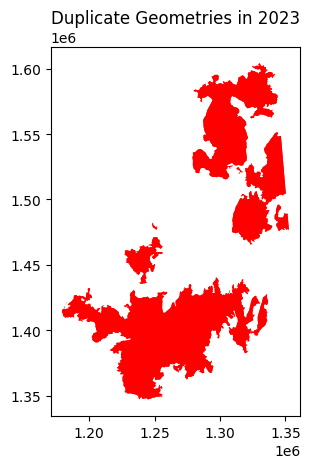

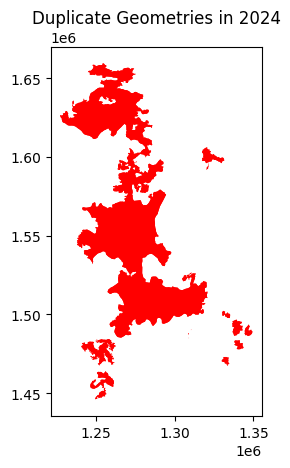

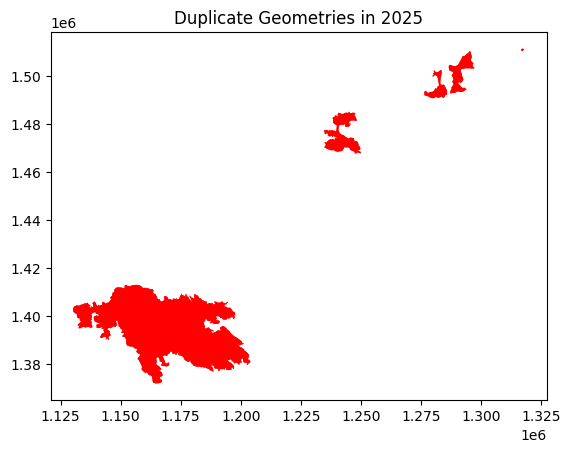

In [37]:
#Visualize duplicate geometries in each year
import matplotlib.pyplot as plt

for year in duplicates['fire_year'].unique():
    fig, ax = plt.subplots()
    duplicates[duplicates['fire_year'] == year].plot(ax=ax, color='red')
    plt.title(f'Duplicate Geometries in {year}')
    plt.show()

In [38]:
# investigate duplicates - are they exact duplicates or just overlapping geometries?
for year in duplicates['fire_year'].unique():
    year_duplicates = duplicates[duplicates['fire_year'] == year]
    for i in range(len(year_duplicates)):
        for j in range(i+1, len(year_duplicates)):
            geom_i = year_duplicates.iloc[i]['geometry']
            geom_j = year_duplicates.iloc[j]['geometry']
            if geom_i.equals(geom_j):
                print(f"Exact duplicate found in {year} between fire_id {year_duplicates.iloc[i]['fire_id']} and {year_duplicates.iloc[j]['fire_id']}")
            elif geom_i.intersects(geom_j):
                print(f"Overlapping geometries found in {year} between fire_id {year_duplicates.iloc[i]['fire_id']} and {year_duplicates.iloc[j]['fire_id']}")

Exact duplicate found in 2023 between fire_id 2023_G90628 and 2023_G90628
Exact duplicate found in 2023 between fire_id 2023_G92498 and 2023_G92498
Exact duplicate found in 2023 between fire_id 2023_G80280 and 2023_G80280
Exact duplicate found in 2023 between fire_id 2023_G90273 and 2023_G90273
Exact duplicate found in 2023 between fire_id 2023_G83130 and 2023_G83130
Exact duplicate found in 2024 between fire_id 2024_G80286 and 2024_G80286
Exact duplicate found in 2024 between fire_id 2024_G80270 and 2024_G80270
Exact duplicate found in 2024 between fire_id 2024_G90228 and 2024_G90228
Exact duplicate found in 2025 between fire_id 2025_G80402 and 2025_G80402
Exact duplicate found in 2025 between fire_id 2025_G80320 and 2025_G80320
Exact duplicate found in 2025 between fire_id 2025_G90406 and 2025_G90406
Exact duplicate found in 2025 between fire_id 2025_G80352 and 2025_G80352
Exact duplicate found in 2025 between fire_id 2025_G90425 and 2025_G90425


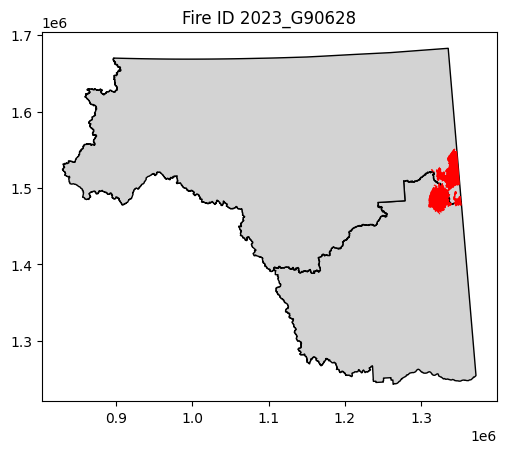

In [23]:
# filter fire_id 2023_G90628 and 2023_G90628
g90628 = fires[fires['fire_id'].isin(['2023_G90628', '2023_G90628'])]

# plot within the study zones to see if they are exact duplicates or just overlapping geometries
fig, ax = plt.subplots()
study_zones.plot(ax=ax, color='lightgrey', edgecolor='black')
g90628.plot(ax=ax, color='red')
plt.title('Fire ID 2023_G90628')
plt.show()

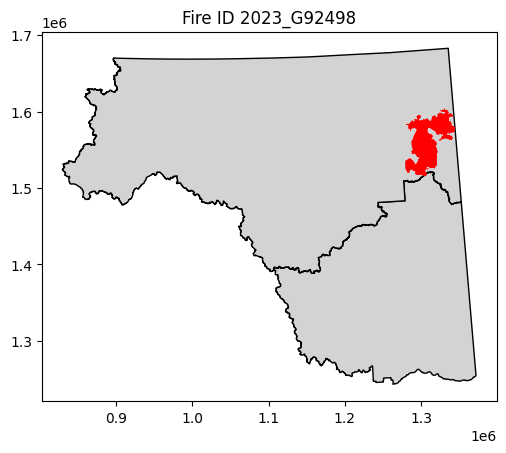

In [24]:
# filter fire_id 2023_G92498
g92498 = fires[fires['fire_id'].isin(['2023_G92498', '2023_G92498'])]
# plot within the study zones to see if they are exact duplicates or just overlapping geometries
fig, ax = plt.subplots()
study_zones.plot(ax=ax, color='lightgrey', edgecolor='black')
g92498.plot(ax=ax, color='red')
plt.title('Fire ID 2023_G92498')
plt.show()

This duplicate is almost certainly due to the clip by study zones. Dissolve by fire_no and change fire_zone column to both

In [39]:
# dissolve by fire_no and change fire_zone column to both if there are multiple fire_zones for the same fire_no
fires['fire_zone'] = fires.groupby('fire_no')['fire_zone'].transform(lambda x: 'both' if len(x.unique()) > 1 else x.iloc[0])
fires = fires.dissolve(by='fire_no', as_index=False, aggfunc='first')


Check for overlapping fire perimeters between years and flag as potential overwintering

In [40]:
# separate by year
fires_2023 = fires[fires['fire_year'] == 2023].copy()
fires_2024 = fires[fires['fire_year'] == 2024].copy()
fires_2025 = fires[fires['fire_year'] == 2025].copy()
# sanity check before proceeding
print(f"2023 fires: {len(fires_2023)} | unique years in split: {fires_2023['fire_id'].str[:4].unique()}")
print(f"2024 fires: {len(fires_2024)} | unique years in split: {fires_2024['fire_id'].str[:4].unique()}")
print(f"2025 fires: {len(fires_2025)} | unique years in split: {fires_2025['fire_id'].str[:4].unique()}")

# --- 2023 vs 2024 ---
overlaps_23_24 = gpd.sjoin(
    fires_2023[['fire_id', 'geometry']],
    fires_2024[['fire_id', 'geometry']],
    how='inner',
    predicate='intersects'
)

# --- 2024 vs 2025 ---
overlaps_24_25 = gpd.sjoin(
    fires_2024[['fire_id', 'geometry']],
    fires_2025[['fire_id', 'geometry']],
    how='inner',
    predicate='intersects'
)

# build lookup dicts
lookup_2023_to_2024 = overlaps_23_24.groupby('fire_id_left')['fire_id_right'].apply(list).to_dict()
lookup_2024_from_2023 = overlaps_23_24.groupby('fire_id_right')['fire_id_left'].apply(list).to_dict()
lookup_2024_to_2025 = overlaps_24_25.groupby('fire_id_left')['fire_id_right'].apply(list).to_dict()
lookup_2025_from_2024 = overlaps_24_25.groupby('fire_id_right')['fire_id_left'].apply(list).to_dict()

# --- build a standalone overlap dataframe indexed by fire_id ---
overlap_records = []

# 2023 fires
for _, row in fires_2023.iterrows():
    fid = row['fire_id']
    overlap_records.append({
        'fire_id': fid,
        'overlap': fid in lookup_2023_to_2024,
        'overlap_year': 2024 if fid in lookup_2023_to_2024 else None,
        'overlap_id': lookup_2023_to_2024.get(fid, None)
    })

# 2024 fires
for _, row in fires_2024.iterrows():
    fid = row['fire_id']
    in_from = fid in lookup_2024_from_2023
    in_to = fid in lookup_2024_to_2025
    overlap_records.append({
        'fire_id': fid,
        'overlap': in_from or in_to,
        'overlap_year': '2023/2025' if in_from and in_to else 2023 if in_from else 2025 if in_to else None,
        'overlap_id': {
            'from_2023': lookup_2024_from_2023.get(fid, []),
            'to_2025': lookup_2024_to_2025.get(fid, [])
        } if in_from or in_to else None
    })

# 2025 fires
for _, row in fires_2025.iterrows():
    fid = row['fire_id']
    overlap_records.append({
        'fire_id': fid,
        'overlap': fid in lookup_2025_from_2024,
        'overlap_year': 2024 if fid in lookup_2025_from_2024 else None,
        'overlap_id': lookup_2025_from_2024.get(fid, None)
    })

overlap_df = pd.DataFrame(overlap_records)

# --- join back to original fires dataframe on fire_id ---
fires = fires.merge(
    overlap_df[['fire_id', 'overlap', 'overlap_year', 'overlap_id']],
    on='fire_id',
    how='left'
)

# --- review ---
potential_overwintering = fires[fires['overlap']]
print(f"Number of potential overwintering fires: {len(potential_overwintering)}")
print(potential_overwintering[['fire_id', 'fire_year', 'overlap', 'overlap_year', 'overlap_id']])

# --- multi-year overwintering candidates (2023 -> 2024 -> 2025) ---
multiyear = []
for _, row in fires[(fires['fire_year'] == 2023) & (fires['overlap'])].iterrows():
    for fid_2024 in row['overlap_id']:
        if fid_2024 in lookup_2024_to_2025:
            multiyear.append({
                'fire_id_2023': row['fire_id'],
                'fire_id_2024': fid_2024,
                'fire_id_2025': lookup_2024_to_2025[fid_2024]
            })

multiyear_df = pd.DataFrame(multiyear)
print(f"\nNumber of multi-year overwintering candidates (2023->2024->2025): {len(multiyear_df)}")
print(multiyear_df)

2023 fires: 80 | unique years in split: <ArrowStringArray>
['2023']
Length: 1, dtype: str
2024 fires: 61 | unique years in split: <ArrowStringArray>
['2024']
Length: 1, dtype: str
2025 fires: 64 | unique years in split: <ArrowStringArray>
['2025']
Length: 1, dtype: str
Number of potential overwintering fires: 50
         fire_id  fire_year  overlap overlap_year  \
31   2024_G80262       2024     True         2023   
32   2024_G80270       2024     True    2023/2025   
34   2023_G80280       2023     True         2024   
35   2024_G80286       2024     True    2023/2025   
40   2025_G80320       2025     True         2024   
44   2025_G80396       2025     True         2024   
45   2025_G80402       2025     True         2024   
46   2025_G80403       2025     True         2024   
49   2025_G80418       2025     True         2024   
52   2024_G80426       2024     True         2023   
53   2025_G80427       2025     True         2024   
90   2023_G82494       2023     True         2024 

In [42]:
# save fires df and multiyear_df
fires.to_file("../data/analysis/all_fires_processed.geojson", driver="GeoJSON")
multiyear_df.to_csv("../data/analysis/multiyear_overwintering.csv", index=False)

# Fire Buffers 
- Create 1000m, 500m, 2000m buffers for 2023 and 2024 only and save as separate files
- Identify fire buffers that spatially overlap across years, (flagged as overwintering before analysis)

In [43]:
# for each row in fires, select fire_id, fire_year and geometry  for 2023 and 2024 only
fires_selected = fires[['fire_id', 'fire_year', 'geometry']]
fires_selected = fires_selected[fires_selected['fire_year'].isin([2023, 2024])]

# calculate three separate datasets with 1000m, 500m and 2000m buffers for 2023 and 2024 only
buffer_distances = [500, 1000, 2000]
buffered_dfs = {}
for dist in buffer_distances:
    buffered_dfs[dist] = fires_selected.copy()
    buffered_dfs[dist]['geometry'] = buffered_dfs[dist]['geometry'].buffer(dist)
    buffered_dfs[dist].to_file(f"../data/analysis/fires_buffer_{dist}m.geojson", driver="GeoJSON")

In [44]:
# separate buffers by year
buffers_2023 = {dist: buffered_dfs[dist][buffered_dfs[dist]['fire_year'] == 2023.0].copy() for dist in buffer_distances}
buffers_2024 = {dist: buffered_dfs[dist][buffered_dfs[dist]['fire_year'] == 2024.0].copy() for dist in buffer_distances}

# separate perimeters by year
perims_2024 = fires[fires['fire_year'] == 2024.0][['fire_id', 'geometry']].copy()
perims_2025 = fires[fires['fire_year'] == 2025.0][['fire_id', 'geometry']].copy()

overlap_records = {}

for dist in buffer_distances:

    # --- 2023 buffers vs 2024 perimeters ---
    overlaps_23_24 = gpd.sjoin(
        buffers_2023[dist][['fire_id', 'geometry']],
        perims_2024[['fire_id', 'geometry']],
        how='inner',
        predicate='intersects'
    ).rename(columns={'fire_id_left': 'fire_id', 'fire_id_right': 'overlap_id'})

    # --- 2024 buffers vs 2025 perimeters ---
    overlaps_24_25 = gpd.sjoin(
        buffers_2024[dist][['fire_id', 'geometry']],
        perims_2025[['fire_id', 'geometry']],
        how='inner',
        predicate='intersects'
    ).rename(columns={'fire_id_left': 'fire_id', 'fire_id_right': 'overlap_id'})

    # build lookup dicts
    lookup_2023_to_2024 = overlaps_23_24.groupby('fire_id')['overlap_id'].apply(list).to_dict()
    lookup_2024_from_2023 = overlaps_23_24.groupby('overlap_id')['fire_id'].apply(list).to_dict()
    lookup_2024_to_2025 = overlaps_24_25.groupby('fire_id')['overlap_id'].apply(list).to_dict()
    lookup_2025_from_2024 = overlaps_24_25.groupby('overlap_id')['fire_id'].apply(list).to_dict()

    # build overlap records for this buffer distance
    records = []

    # 2023 fires
    for _, row in fires[fires['fire_year'] == 2023.0].iterrows():
        fid = row['fire_id']
        records.append({
            'fire_id': fid,
            'fire_year': 2023,
            'overlap': fid in lookup_2023_to_2024,
            'overlap_year': 2024 if fid in lookup_2023_to_2024 else None,
            'overlap_id': lookup_2023_to_2024.get(fid, None)
        })

    # 2024 fires
    for _, row in fires[fires['fire_year'] == 2024.0].iterrows():
        fid = row['fire_id']
        in_from = fid in lookup_2024_from_2023
        in_to = fid in lookup_2024_to_2025
        records.append({
            'fire_id': fid,
            'fire_year': 2024,
            'overlap': in_from or in_to,
            'overlap_year': '2023/2025' if in_from and in_to else 2023 if in_from else 2025 if in_to else None,
            'overlap_id': {
                'from_2023': lookup_2024_from_2023.get(fid, []),
                'to_2025': lookup_2024_to_2025.get(fid, [])
            } if in_from or in_to else None
        })

    # 2025 fires
    for _, row in fires[fires['fire_year'] == 2025.0].iterrows():
        fid = row['fire_id']
        records.append({
            'fire_id': fid,
            'fire_year': 2025,
            'overlap': fid in lookup_2025_from_2024,
            'overlap_year': 2024 if fid in lookup_2025_from_2024 else None,
            'overlap_id': lookup_2025_from_2024.get(fid, None)
        })

    overlap_records[dist] = pd.DataFrame(records)

# --- join each buffer distance back to original fires dataframe ---
for dist in buffer_distances:
    suffix = f'_{dist}m'
    fires = fires.merge(
        overlap_records[dist][['fire_id', 'overlap', 'overlap_year', 'overlap_id']].rename(columns={
            'overlap': f'overlap{suffix}',
            'overlap_year': f'overlap_year{suffix}',
            'overlap_id': f'overlap_id{suffix}'
        }),
        on='fire_id',
        how='left'
    )

# --- review ---
for dist in buffer_distances:
    suffix = f'_{dist}m'
    potential = fires[fires[f'overlap{suffix}'] == True]
    print(f"\nBuffer {dist}m — potential overwintering fires: {len(potential)}")
    print(potential[['fire_id', 'fire_year', f'overlap{suffix}', f'overlap_year{suffix}', f'overlap_id{suffix}']])

# --- multi-year overwintering candidates (2023 -> 2024 -> 2025) per buffer distance ---
for dist in buffer_distances:
    suffix = f'_{dist}m'
    lookup_2023_to_2024 = {}
    lookup_2024_to_2025 = {}

    for _, row in fires[(fires['fire_year'] == 2023.0) & (fires[f'overlap{suffix}'] == True)].iterrows():
        lookup_2023_to_2024[row['fire_id']] = row[f'overlap_id{suffix}']

    for _, row in fires[(fires['fire_year'] == 2024.0) & (fires[f'overlap{suffix}'] == True)].iterrows():
        if isinstance(row[f'overlap_id{suffix}'], dict):
            lookup_2024_to_2025[row['fire_id']] = row[f'overlap_id{suffix}'].get('to_2025', [])

    multiyear = []
    for fid_2023, fids_2024 in lookup_2023_to_2024.items():
        for fid_2024 in fids_2024:
            if fid_2024 in lookup_2024_to_2025:
                multiyear.append({
                    'fire_id_2023': fid_2023,
                    'fire_id_2024': fid_2024,
                    'fire_id_2025': lookup_2024_to_2025[fid_2024]
                })

    multiyear_df = pd.DataFrame(multiyear)
    print(f"\nBuffer {dist}m — multi-year overwintering candidates (2023->2024->2025): {len(multiyear_df)}")
    print(multiyear_df)


Buffer 500m — potential overwintering fires: 56
         fire_id  fire_year  overlap_500m overlap_year_500m  \
31   2024_G80262       2024          True              2023   
32   2024_G80270       2024          True         2023/2025   
34   2023_G80280       2023          True              2024   
35   2024_G80286       2024          True         2023/2025   
40   2025_G80320       2025          True              2024   
44   2025_G80396       2025          True              2024   
45   2025_G80402       2025          True              2024   
46   2025_G80403       2025          True              2024   
49   2025_G80418       2025          True              2024   
52   2024_G80426       2024          True              2023   
53   2025_G80427       2025          True              2024   
71   2024_G80854       2024          True              2023   
80   2023_G81530       2023          True              2024   
90   2023_G82494       2023          True              2024   
93   2

In [48]:
# initialise overlap_records dict before the loop
overlap_records = {}
all_lookups = {}

for dist in buffer_distances:

    # --- 2023 buffers vs 2024 perimeters ---
    overlaps_23_24 = gpd.sjoin(
        buffers_2023[dist][['fire_id', 'geometry']],
        perims_2024[['fire_id', 'geometry']],
        how='inner',
        predicate='intersects'
    ).rename(columns={'fire_id_left': 'fire_id', 'fire_id_right': 'overlap_id'})

    # --- 2024 buffers vs 2025 perimeters ---
    overlaps_24_25 = gpd.sjoin(
        buffers_2024[dist][['fire_id', 'geometry']],
        perims_2025[['fire_id', 'geometry']],
        how='inner',
        predicate='intersects'
    ).rename(columns={'fire_id_left': 'fire_id', 'fire_id_right': 'overlap_id'})

    # build and store lookup dicts for this buffer distance
    lookup_2023_to_2024 = overlaps_23_24.groupby('fire_id')['overlap_id'].apply(list).to_dict()
    lookup_2024_from_2023 = overlaps_23_24.groupby('overlap_id')['fire_id'].apply(list).to_dict()
    lookup_2024_to_2025 = overlaps_24_25.groupby('fire_id')['overlap_id'].apply(list).to_dict()
    lookup_2025_from_2024 = overlaps_24_25.groupby('overlap_id')['fire_id'].apply(list).to_dict()

    all_lookups[dist] = {
        '2023_to_2024': lookup_2023_to_2024,
        '2024_from_2023': lookup_2024_from_2023,
        '2024_to_2025': lookup_2024_to_2025,
        '2025_from_2024': lookup_2025_from_2024
    }

    # build overlap records
    records = []

    for _, row in fires[fires['fire_year'] == 2023.0].iterrows():
        fid = row['fire_id']
        records.append({
            'fire_id': fid,
            'fire_year': 2023,
            'overlap': fid in lookup_2023_to_2024,
            'overlap_year': 2024 if fid in lookup_2023_to_2024 else None,
            'overlap_id': lookup_2023_to_2024.get(fid, None)
        })

    for _, row in fires[fires['fire_year'] == 2024.0].iterrows():
        fid = row['fire_id']
        in_from = fid in lookup_2024_from_2023
        in_to = fid in lookup_2024_to_2025
        records.append({
            'fire_id': fid,
            'fire_year': 2024,
            'overlap': in_from or in_to,
            'overlap_year': '2023/2025' if in_from and in_to else 2023 if in_from else 2025 if in_to else None,
            'overlap_id': {
                'from_2023': lookup_2024_from_2023.get(fid, []),
                'to_2025': lookup_2024_to_2025.get(fid, [])
            } if in_from or in_to else None
        })

    for _, row in fires[fires['fire_year'] == 2025.0].iterrows():
        fid = row['fire_id']
        records.append({
            'fire_id': fid,
            'fire_year': 2025,
            'overlap': fid in lookup_2025_from_2024,
            'overlap_year': 2024 if fid in lookup_2025_from_2024 else None,
            'overlap_id': lookup_2025_from_2024.get(fid, None)
        })

    overlap_records[dist] = pd.DataFrame(records)

    # checkpoint: verify records built correctly
    print(f"\nBuffer {dist}m:")
    print(f"  overlap_records shape: {overlap_records[dist].shape}")
    print(f"  overlap_records columns: {overlap_records[dist].columns.tolist()}")
    print(f"  fires with overlap=True: {overlap_records[dist]['overlap'].sum()}")

# --- join each buffer distance back to original fires dataframe ---
# checkpoint: confirm fires columns before merge
print(f"\nfires columns before merge: {fires.columns.tolist()}")

for dist in buffer_distances:
    suffix = f'_{dist}m'
    merge_df = overlap_records[dist][['fire_id', 'overlap', 'overlap_year', 'overlap_id']].rename(columns={
        'overlap': f'overlap{suffix}',
        'overlap_year': f'overlap_year{suffix}',
        'overlap_id': f'overlap_id{suffix}'
    })

    # checkpoint: verify merge_df before joining
    print(f"\nBuffer {dist}m merge_df:")
    print(f"  columns: {merge_df.columns.tolist()}")
    print(f"  shape: {merge_df.shape}")
    print(f"  fire_id sample: {merge_df['fire_id'].head(3).tolist()}")

    fires = fires.merge(merge_df, on='fire_id', how='left')

    # checkpoint: verify columns added successfully
    print(f"  fires columns after merge: {[c for c in fires.columns if 'overlap' in c]}")

# --- review and multi-year per buffer distance ---
multiyear_dfs = {}

for dist in buffer_distances:
    suffix = f'_{dist}m'
    lookups = all_lookups[dist]

    potential = fires[fires[f'overlap{suffix}'] == True]
    print(f"\nBuffer {dist}m — potential overwintering fires: {len(potential)}")
    print(potential[['fire_id', 'fire_year', f'overlap{suffix}', f'overlap_year{suffix}', f'overlap_id{suffix}']])

    # multi-year: 2023 fire whose overlapping 2024 fire also overlaps into 2025
    multiyear = []
    for fid_2023, fids_2024 in lookups['2023_to_2024'].items():
        for fid_2024 in fids_2024:
            if fid_2024 in lookups['2024_to_2025']:
                multiyear.append({
                    'fire_id_2023': fid_2023,
                    'fire_id_2024': fid_2024,
                    'fire_id_2025': lookups['2024_to_2025'][fid_2024]
                })

    multiyear_dfs[dist] = pd.DataFrame(multiyear)
    print(f"\nBuffer {dist}m — multi-year overwintering candidates (2023->2024->2025): {len(multiyear_dfs[dist])}")
    print(multiyear_dfs[dist])


Buffer 500m:
  overlap_records shape: (205, 5)
  overlap_records columns: ['fire_id', 'fire_year', 'overlap', 'overlap_year', 'overlap_id']
  fires with overlap=True: 56

Buffer 1000m:
  overlap_records shape: (205, 5)
  overlap_records columns: ['fire_id', 'fire_year', 'overlap', 'overlap_year', 'overlap_id']
  fires with overlap=True: 58

Buffer 2000m:
  overlap_records shape: (205, 5)
  overlap_records columns: ['fire_id', 'fire_year', 'overlap', 'overlap_year', 'overlap_id']
  fires with overlap=True: 62

fires columns before merge: ['fire_no', 'geometry', 'version_no', 'fire_year', 'fire_cause', 'firelabel', 'size_ha', 'source', 'track_date', 'load_date', 'fire_date', 'method', 'fcode', 'shape', 'objectid', 'area_sqm', 'feat_len', 'fire_stat', 'fire_url', 'fire_id', 'fire_zone', 'fire_month', 'fire_doy', 'geometry_wkt', 'overlap', 'overlap_year', 'overlap_id', 'overlap_500m_x', 'overlap_year_500m_x', 'overlap_id_500m_x', 'overlap_1000m_x', 'overlap_year_1000m_x', 'overlap_id_1000

In [45]:
# from fires, drop all columns that are not fire_id, fire_year or have overlap in name, also drop geometry
fires_buff_overlap = fires[[col for col in fires.columns if col in ['fire_id', 'fire_year'] or 'overlap' in col]]
fires_buff_overlap.to_csv("../data/analysis/fires_with_buffer_overlaps.csv", index=False)

In [49]:
for dist in buffer_distances:
    multiyear_dfs[dist].to_csv(f"../data/analysis/multiyear_overwintering_{dist}m.csv", index=False)
    print(f"Saved multiyear_overwintering_{dist}m.csv")


Saved multiyear_overwintering_500m.csv
Saved multiyear_overwintering_1000m.csv
Saved multiyear_overwintering_2000m.csv


# Snowmelt Onset day

- Extract mean snowmelt onset date for each fire buffer.
- min/max snowmelt onset date per buffer
- store as new columns in fire buffers

In [57]:
fires_buffer_1000m = gpd.read_file("../data/analysis/fires_buffer_1000m.geojson").query("fire_year in [2023, 2024]")
fires_buffer_500m = gpd.read_file("../data/analysis/fires_buffer_500m.geojson").query("fire_year in [2023, 2024]")
fires_buffer_2000m = gpd.read_file("../data/analysis/fires_buffer_2000m.geojson").query("fire_year in [2023, 2024]")

buffered_dfs = {
    500: fires_buffer_500m,
    1000: fires_buffer_1000m,
    2000: fires_buffer_2000m
}


In [58]:
from rasterstats import zonal_stats

def extract_sdd_stats(buffered_dfs, sdd_rasters, buffer_distances, years=[2024, 2025]):
    """
    Extract snowmelt onset date (SDD) statistics for each fire buffer.
    
    Parameters
    ----------
    buffered_dfs : dict
        Dictionary of buffered GeoDataFrames keyed by buffer distance e.g. {500: gdf, 1000: gdf, 2000: gdf}
    sdd_rasters : dict
        Dictionary of paths to SDD rasters keyed by year e.g. {2024: 'path/to/sdd_2024.tif', 2025: 'path/to/sdd_2025.tif'}
    buffer_distances : list
        List of buffer distances e.g. [500, 1000, 2000]
    years : list
        List of years to extract SDD for, corresponding to keys in sdd_rasters

    Returns
    -------
    buffered_dfs : dict
        Updated buffered_dfs with SDD columns added per year
    """

    for dist in buffer_distances:
        gdf = buffered_dfs[dist].copy()

        for year in years:
            raster_path = sdd_rasters[year]

            # open raster to get nodata value
            with rasterio.open(raster_path) as src:
                nodata = src.nodata
                raster_crs = src.crs
                print(f"Buffer {dist}m | SDD {year} | raster CRS: {raster_crs} | nodata: {nodata}")

            # ensure buffer CRS matches raster CRS
            gdf_proj = gdf.to_crs(raster_crs) if gdf.crs != raster_crs else gdf

            # only extract for fires of the relevant year
            # 2024 SDD applies to 2023 buffers (overwintering into 2024 spring)
            # 2025 SDD applies to 2024 buffers (overwintering into 2025 spring)
            fire_year = year - 1
            mask = gdf_proj['fire_year'] == float(fire_year)

            # initialise columns as NaN
            gdf[f'sdd_{year}_mean'] = np.nan
            gdf[f'sdd_{year}_min'] = np.nan
            gdf[f'sdd_{year}_max'] = np.nan

            if mask.sum() == 0:
                print(f"  No fires for year {fire_year} in buffer {dist}m, skipping")
                continue

            # run zonal stats on relevant subset
            stats = zonal_stats(
                gdf_proj[mask],
                raster_path,
                stats=['mean', 'min', 'max'],
                nodata=nodata,
                all_touched=False  # only pixels whose centroid falls within buffer
            )

            # assign back to correct rows using index
            subset_idx = gdf[mask].index
            gdf.loc[subset_idx, f'sdd_{year}_mean'] = [s['mean'] for s in stats]
            gdf.loc[subset_idx, f'sdd_{year}_min']  = [s['min']  for s in stats]
            gdf.loc[subset_idx, f'sdd_{year}_max']  = [s['max']  for s in stats]

            print(f"  Buffer {dist}m | SDD {year} | extracted for {mask.sum()} fires")
            print(gdf.loc[subset_idx, ['fire_id', 'fire_year', f'sdd_{year}_mean', f'sdd_{year}_min', f'sdd_{year}_max']].head())

        buffered_dfs[dist] = gdf

    return buffered_dfs

In [59]:
sdd_rasters = {
    2024: '../data/snow_dd/SDD_2024.tif',
    2025: '../data/snow_dd/SDD_2025.tif'
}

buffered_dfs = extract_sdd_stats(buffered_dfs, sdd_rasters, buffer_distances)

Buffer 500m | SDD 2024 | raster CRS: EPSG:4326 | nodata: None
  Buffer 500m | SDD 2024 | extracted for 80 fires
       fire_id  fire_year  sdd_2024_mean  sdd_2024_min  sdd_2024_max
1  2023_G80035       2023      80.541667          76.0         103.0
3  2023_G80052       2023      89.875000          66.0         152.0
4  2023_G80053       2023      82.000000          82.0          82.0
7  2023_G80076       2023      80.333333          70.0          82.0
8  2023_G80117       2023      94.090909          67.0         104.0
Buffer 500m | SDD 2025 | raster CRS: EPSG:4326 | nodata: None
  Buffer 500m | SDD 2025 | extracted for 61 fires
        fire_id  fire_year  sdd_2025_mean  sdd_2025_min  sdd_2025_max
0   2024_G80016       2024      96.625000          90.0         103.0
2   2024_G80036       2024      66.153846           0.0         116.0
5   2024_G80062       2024      63.090909          47.0          86.0
6   2024_G80071       2024     116.833333         114.0         123.0
13  2024_G80

In [60]:
# save as sdd
for dist in buffer_distances:
    buffered_dfs[dist].to_file(f"../data/analysis/fires_buffer_{dist}m_with_sdd.geojson", driver="GeoJSON")
    print(f"Saved fires_buffer_{dist}m_with_sdd.geojson")

Saved fires_buffer_500m_with_sdd.geojson
Saved fires_buffer_1000m_with_sdd.geojson
Saved fires_buffer_2000m_with_sdd.geojson


# Hotspots

- Apply quality filters upfront
- daynight == "N"
- confidence != "l"
- scan <=0.5 & track <=0.5
- Convert acq_date and acq_time to a proper datetime field and extract DOY, month, year as columns
- Separate into annual hotspot layers and save separately
- Further split each annual layer into fall and spring subsets (could just be a column) based on DOY
- Fall: after august 1 (DOY 213)
- Spring: after snowmelt DOY through end of june
- Holdover: period between august 1 and snowmelt DOY

In [ ]:
all_htspt = gpd.read_file("../firms_output/all_hotspots_2023_2025.geojson")
all_htspt.head()

In [ ]:
# filter out acq_date before 2023-09-01
all_htspt["acq_date"] = pd.to_datetime(all_htspt["acq_date"])
all_htspt = all_htspt[all_htspt["acq_date"] >= "2023-09-01"]
all_htspt.head()

In [ ]:
# filter out daynight == "N"
all_htspt = all_htspt[all_htspt["daynight"] == "N"]
all_htspt.head()

In [ ]:
# count how many column remove if scane <= 0.5 and track <= 0.5
all_htspt_2 = all_htspt[(all_htspt["scan"] > 0.5) & (all_htspt["track"] > 0.5)]
all_htspt_2.head()

In [ ]:
# filter condifence to n and h for both
all_htspt_2 = all_htspt_2[all_htspt_2["confidence"].isin(["n", "h"])]
all_htspt_2.head()
all_htspt = all_htspt[all_htspt["confidence"].isin(["n", "h"])]
all_htspt.head()

In [ ]:
# for both datasets get day, month and year columns
all_htspt["day"] = all_htspt["acq_date"].dt.day
all_htspt["month"] = all_htspt["acq_date"].dt.month
all_htspt["year"] = all_htspt["acq_date"].dt.year
all_htspt_2["day"] = all_htspt_2["acq_date"].dt.day
all_htspt_2["month"] = all_htspt_2["acq_date"].dt.month
all_htspt_2["year"] = all_htspt_2["acq_date"].dt.year

In [ ]:
# save both to ../data/analysis/
all_htspt.to_file("../data/analysis/all_hotspots_2023_2025_night_nh.geojson", driver="GeoJSON")
all_htspt_2.to_file("../data/analysis/all_hotspots_2023_2025_night_nh_scan_track.geojson", driver="GeoJSON")